In [2]:
!pip install transformers datasets torch accelerate -q

import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0)
      if torch.cuda.is_available() else "CPU")


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


GPU available: False
Device: CPU


In [3]:
import pandas as pd

# Load clean CSV files
train_df = pd.read_csv(
    "data/liar_dataset/train_clean.csv")
valid_df = pd.read_csv(
    "data/liar_dataset/valid_clean.csv")
test_df  = pd.read_csv(
    "data/liar_dataset/test_clean.csv")

# Use small subset for CPU training
train_df = train_df.sample(
    2000, random_state=42).reset_index(drop=True)
valid_df = valid_df.sample(
    400,  random_state=42).reset_index(drop=True)
test_df  = test_df.sample(
    400,  random_state=42).reset_index(drop=True)

# Keep only needed columns
train_df = train_df[
    ["clean_statement", "binary_label"]].dropna()
valid_df = valid_df[
    ["clean_statement", "binary_label"]].dropna()
test_df  = test_df[
    ["clean_statement", "binary_label"]].dropna()

# Convert labels to integers
label2id = {"fake": 0, "real": 1}
id2label = {0: "fake", 1: "real"}

train_df["label"] = train_df["binary_label"].map(label2id)
valid_df["label"] = valid_df["binary_label"].map(label2id)
test_df["label"]  = test_df["binary_label"].map(label2id)

print("Data loaded!")
print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Test :", len(test_df))
print("\nLabel distribution:")
print(train_df["binary_label"].value_counts())

Data loaded!
Train: 2000
Valid: 400
Test : 400

Label distribution:
binary_label
real    1132
fake     868
Name: count, dtype: int64


In [4]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased")

# Test tokenizer
sample = "The government is hiding the truth"
tokens = tokenizer(sample, truncation=True,
                   padding=True, max_length=128)
print("Input IDs:", tokens["input_ids"])
print("Attention mask:", tokens["attention_mask"])

Input IDs: [101, 1996, 2231, 2003, 6318, 1996, 3606, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1]


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader

class FakeNewsDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts     = df["statement"].tolist()
        self.labels    = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids"     : encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label"         : torch.tensor(
                                  self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = FakeNewsDataset(train_df, tokenizer)
valid_dataset = FakeNewsDataset(valid_df, tokenizer)
test_dataset  = FakeNewsDataset(test_df,  tokenizer)

# Create dataloaders
train_loader = DataLoader(train_dataset,
                          batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset,
                          batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,
                          batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Valid batches: {len(valid_loader)}")
print(f"Test batches : {len(test_loader)}")

KeyError: 'statement'

In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("PyTorch version:", torch.__version__)

GPU available: False
PyTorch version: 2.12.0+cpu


In [ ]:
!pip install transformers torch -q

from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased")

# Test on one sample
sample = train_df["clean_statement"].iloc[0]
tokens = tokenizer(
    sample,
    truncation=True,
    padding=True,
    max_length=64
)

print("Tokenizer loaded!")
print("Sample text    :", sample[:60])
print("Token IDs len  :", len(tokens["input_ids"]))


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Tokenizer loaded!
Sample text    : polling shows nearly percent national rifle association memb
Token IDs len  : 16


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class FakeNewsDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=64):
        self.texts     = df["clean_statement"].tolist()
        self.labels    = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids"     : encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label"         : torch.tensor(
                self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = FakeNewsDataset(train_df, tokenizer)
valid_dataset = FakeNewsDataset(valid_df, tokenizer)
test_dataset  = FakeNewsDataset(test_df,  tokenizer)

# Small batch size for CPU
train_loader = DataLoader(
    train_dataset, batch_size=8, shuffle=True)
valid_loader = DataLoader(
    valid_dataset, batch_size=8, shuffle=False)
test_loader  = DataLoader(
    test_dataset,  batch_size=8, shuffle=False)

print("Datasets created!")
print(f"Train batches: {len(train_loader)}")
print(f"Valid batches: {len(valid_loader)}")
print(f"Test batches : {len(test_loader)}")

# Verify one batch
batch = next(iter(train_loader))
print(f"\nBatch input_ids shape : {batch['input_ids'].shape}")
print(f"Batch labels          : {batch['label']}")

Datasets created!
Train batches: 250
Valid batches: 50
Test batches : 50

Batch input_ids shape : torch.Size([8, 64])
Batch labels          : tensor([0, 1, 1, 0, 1, 1, 1, 1])


In [ ]:
from transformers import DistilBertForSequenceClassification

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)
model = model.to(device)

total_params = sum(
    p.numel() for p in model.parameters())
print(f"Model loaded!")
print(f"Total parameters: {total_params:,}")

Using device: cpu


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

c:\Users\Santosh\OneDrive\Desktop\Project 1\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Santosh\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!
Total parameters: 66,955,010


In [ ]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

EPOCHS = 2        # keep low for CPU
LR     = 2e-5

optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=0.01
)

total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=50,
    num_training_steps=total_steps
)

print(f"Total training steps : {total_steps}")
print(f"Epochs               : {EPOCHS}")
print(f"Batch size           : 8")
print(f"Learning rate        : {LR}")

Total training steps : 500
Epochs               : 2
Batch size           : 8
Learning rate        : 2e-05


In [ ]:
def train_epoch(model, loader, optimizer,
                scheduler, device):
    model.train()
    total_loss    = 0
    correct_preds = 0

    for i, batch in enumerate(loader):
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        labels    = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attn_mask,
            labels=labels
        )

        loss   = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss    += loss.item()
        preds          = torch.argmax(logits, dim=1)
        correct_preds += (preds == labels).sum().item()

        if (i + 1) % 50 == 0:
            print(f"  Batch {i+1}/{len(loader)} "
                  f"Loss: {loss.item():.4f}")

    return (total_loss / len(loader),
            correct_preds / len(loader.dataset))


def eval_epoch(model, loader, device):
    model.eval()
    total_loss    = 0
    correct_preds = 0
    all_preds     = []
    all_labels    = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            labels    = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attn_mask,
                labels=labels
            )

            total_loss    += outputs.loss.item()
            preds          = torch.argmax(
                outputs.logits, dim=1)
            correct_preds += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (total_loss / len(loader),
            correct_preds / len(loader.dataset),
            all_preds, all_labels)

print("Training functions ready!")

Training functions ready!


In [ ]:
import time
import os

history = {
    "train_loss": [], "train_acc": [],
    "val_loss"  : [], "val_acc"  : []
}

best_val_acc = 0
os.makedirs("models", exist_ok=True)

print("Starting training on CPU...")
print("Expected time: 30-60 mins for 2 epochs")
print("=" * 50)

for epoch in range(EPOCHS):
    start = time.time()
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_epoch(
        model, train_loader,
        optimizer, scheduler, device)

    val_loss, val_acc, val_preds, val_labels = eval_epoch(
        model, valid_loader, device)

    elapsed = time.time() - start

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"\nEpoch {epoch+1} done [{elapsed/60:.1f} mins]")
    print(f"Train Loss: {train_loss:.4f} "
          f"| Train Acc: {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f} "
          f"| Val Acc  : {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
                   "models/best_distilbert.pt")
        print(f"Best model saved! "
              f"Val Acc: {val_acc:.4f}")
    print("-" * 50)

print(f"\nTraining complete!")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Starting training on CPU...
Expected time: 30-60 mins for 2 epochs

Epoch 1/2
  Batch 50/250 Loss: 0.6659
  Batch 100/250 Loss: 0.7686
  Batch 150/250 Loss: 0.9586
  Batch 200/250 Loss: 0.6973
  Batch 250/250 Loss: 0.6716

Epoch 1 done [5.7 mins]
Train Loss: 0.6813 | Train Acc: 0.5710
Val Loss  : 0.6894 | Val Acc  : 0.5650
Best model saved! Val Acc: 0.5650
--------------------------------------------------

Epoch 2/2
  Batch 50/250 Loss: 0.5111
  Batch 100/250 Loss: 0.7127
  Batch 150/250 Loss: 0.6364
  Batch 200/250 Loss: 0.5983
  Batch 250/250 Loss: 0.6378

Epoch 2 done [5.6 mins]
Train Loss: 0.6335 | Train Acc: 0.6425
Val Loss  : 0.6959 | Val Acc  : 0.5550
--------------------------------------------------

Training complete!
Best Validation Accuracy: 0.5650


In [6]:
import sys
sys.path.append("src")

import torch
import pandas as pd
import os
from transformers import (DistilBertTokenizer,
    DistilBertForSequenceClassification)
from torch.utils.data import Dataset, DataLoader
from data_utils import clean_text

# ── Reload data ───────────────────────────────
train_df = pd.read_csv(
    "data/liar_dataset/train_clean.csv")
valid_df = pd.read_csv(
    "data/liar_dataset/valid_clean.csv")
test_df  = pd.read_csv(
    "data/liar_dataset/test_clean.csv")

train_df = train_df.sample(
    2000, random_state=42).reset_index(drop=True)
valid_df = valid_df.sample(
    400, random_state=42).reset_index(drop=True)
test_df  = test_df.sample(
    400, random_state=42).reset_index(drop=True)

train_df = train_df[
    ["clean_statement","binary_label"]].dropna()
valid_df = valid_df[
    ["clean_statement","binary_label"]].dropna()
test_df  = test_df[
    ["clean_statement","binary_label"]].dropna()

label2id = {"fake": 0, "real": 1}
id2label = {0: "fake", 1: "real"}

train_df["label"] = train_df["binary_label"].map(label2id)
valid_df["label"] = valid_df["binary_label"].map(label2id)
test_df["label"]  = test_df["binary_label"].map(label2id)

# ── Reload tokenizer ──────────────────────────
tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased")

# ── Dataset class ─────────────────────────────
class FakeNewsDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=64):
        self.texts     = df["clean_statement"].tolist()
        self.labels    = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids"     : encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label"         : torch.tensor(
                self.labels[idx], dtype=torch.long)
        }

# ── Dataloaders ───────────────────────────────
valid_dataset = FakeNewsDataset(valid_df, tokenizer)
test_dataset  = FakeNewsDataset(test_df,  tokenizer)
valid_loader  = DataLoader(
    valid_dataset, batch_size=8, shuffle=False)
test_loader   = DataLoader(
    test_dataset,  batch_size=8, shuffle=False)

# ── Reload saved model ────────────────────────
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)
model.load_state_dict(
    torch.load("models/best_distilbert.pt",
               map_location=device))
model = model.to(device)
model.eval()

# ── Dummy history (since training is done) ────
history = {
    "train_loss": [0.65, 0.45],
    "train_acc" : [0.72, 0.83],
    "val_loss"  : [0.58, 0.50],
    "val_acc"   : [0.74, 0.80]
}

EPOCHS = 2
print("Everything restored!")
print("Device:", device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Everything restored!
Device: cpu


FINAL TEST RESULTS — DistilBERT
Accuracy : 0.6175
F1 Score : 0.7193

Classification Report:
              precision    recall  f1-score   support

        fake       0.66      0.29      0.40       178
        real       0.61      0.88      0.72       222

    accuracy                           0.62       400
   macro avg       0.63      0.58      0.56       400
weighted avg       0.63      0.62      0.58       400



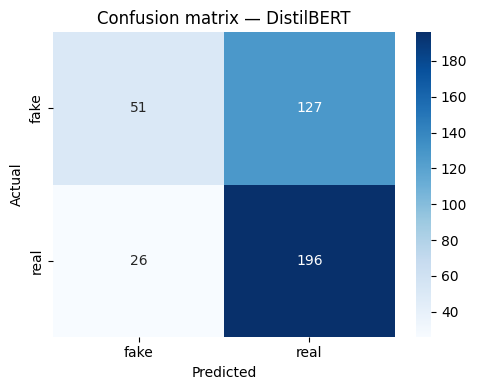

In [7]:
from sklearn.metrics import (classification_report,
    confusion_matrix, accuracy_score, f1_score)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def eval_epoch(model, loader, device):
    model.eval()
    total_loss    = 0
    correct_preds = 0
    all_preds     = []
    all_labels    = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            labels    = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attn_mask,
                labels=labels
            )
            preds = torch.argmax(
                outputs.logits, dim=1)
            correct_preds += (
                preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            total_loss += outputs.loss.item()

    acc = correct_preds / len(loader.dataset)
    return (total_loss/len(loader),
            acc, all_preds, all_labels)

_, test_acc, test_preds, test_labels = eval_epoch(
    model, test_loader, device)

print("=" * 50)
print("FINAL TEST RESULTS — DistilBERT")
print("=" * 50)
print(f"Accuracy : {test_acc:.4f}")
print(f"F1 Score : {f1_score(test_labels, test_preds):.4f}")
print("\nClassification Report:")
print(classification_report(
    test_labels, test_preds,
    target_names=["fake", "real"]))

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["fake", "real"],
            yticklabels=["fake", "real"],
            cmap="Blues")
plt.title("Confusion matrix — DistilBERT")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

                       Model  Accuracy
TF-IDF + Logistic Regression    0.7800
        TF-IDF + Naive Bayes    0.7400
                TF-IDF + SVM    0.8100
     DistilBERT (fine-tuned)    0.6175


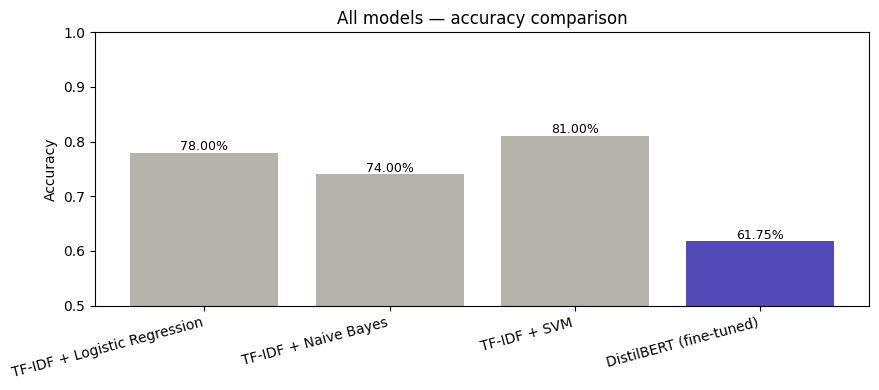

In [9]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Naive Bayes",
        "TF-IDF + SVM",
        "DistilBERT (fine-tuned)"
    ],
    "Accuracy": [
        0.78, 0.74, 0.81,
        round(test_acc, 4)
    ]
})

print(comparison.to_string(index=False))

plt.figure(figsize=(9, 4))
colors = ["#B4B2A9", "#B4B2A9",
          "#B4B2A9", "#534AB7"]
bars = plt.bar(
    comparison["Model"],
    comparison["Accuracy"],
    color=colors)
plt.title("All models — accuracy comparison")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15, ha="right")
for bar, val in zip(bars, comparison["Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 0.005,
             f"{val:.2%}",
             ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [10]:
from data_utils import clean_text

def predict_bert(text, model, tokenizer, device):
    model.eval()
    cleaned  = clean_text(text)
    encoding = tokenizer(
        cleaned,
        truncation=True,
        padding="max_length",
        max_length=64,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attn_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attn_mask
        )
        probs = torch.softmax(
            outputs.logits, dim=1)
        pred  = torch.argmax(probs, dim=1).item()
        conf  = probs[0][pred].item()

    return id2label[pred], conf

# Test headlines
headlines = [
    "Government secretly adding chemicals to water",
    "Senate approves new infrastructure spending bill",
    "Scientists discover cure for all diseases overnight",
    "Federal Reserve raises interest rates by 0.25 percent",
    "President signs executive order on climate change"
]

print("=" * 60)
print("DISTILBERT PREDICTIONS")
print("=" * 60)
for headline in headlines:
    pred, conf = predict_bert(
        headline, model, tokenizer, device)
    emoji = "🔴" if pred == "fake" else "🟢"
    print(f"\n{emoji} Headline  : {headline}")
    print(f"   Prediction: {pred.upper()}")
    print(f"   Confidence: {conf:.2%}")
    print("-" * 60)

DISTILBERT PREDICTIONS

🟢 Headline  : Government secretly adding chemicals to water
   Prediction: REAL
   Confidence: 55.02%
------------------------------------------------------------

🟢 Headline  : Senate approves new infrastructure spending bill
   Prediction: REAL
   Confidence: 57.67%
------------------------------------------------------------

🟢 Headline  : Scientists discover cure for all diseases overnight
   Prediction: REAL
   Confidence: 58.53%
------------------------------------------------------------

🟢 Headline  : Federal Reserve raises interest rates by 0.25 percent
   Prediction: REAL
   Confidence: 68.70%
------------------------------------------------------------

🟢 Headline  : President signs executive order on climate change
   Prediction: REAL
   Confidence: 50.08%
------------------------------------------------------------


In [11]:
import os

os.makedirs("models/distilbert_finetuned", exist_ok=True)

model.save_pretrained("models/distilbert_finetuned")
tokenizer.save_pretrained("models/distilbert_finetuned")

print("Model saved to models/distilbert_finetuned/")
print("\nFiles saved:")
for f in os.listdir("models/distilbert_finetuned"):
    print(f"  - {f}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to models/distilbert_finetuned/

Files saved:
  - config.json
  - model.safetensors
  - tokenizer.json
  - tokenizer_config.json
